In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"
DEVICE='cuda:0'

In [3]:
import sys
sys.path.append(os.path.realpath('../../'))

In [4]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, pipeline

model_name = "deepset/roberta-large-squad2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name, cache_dir="/mount/arbeitsdaten/asr-2/vaethdk/resources/weights/").to(DEVICE)

In [5]:
import torch

In [11]:
nlp = pipeline('question-answering', model=model_name, tokenizer=model_name, device=DEVICE, cache_dir="/mount/arbeitsdaten/asr-2/vaethdk/resources/weights/")

In [13]:
QA_input = {
    'question': 'What do we need?',
    'context': 'Computers are neccessary for daily life.'
}
res = nlp(QA_input)

In [14]:
res

{'score': 0.9104037284851074, 'start': 0, 'end': 9, 'answer': 'Computers'}

In [15]:
from data.dataset import GraphDataset, ReimburseGraphDataset, DataAugmentationLevel, DialogNode, NodeType

In [16]:
human_data_train = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
human_data_test = ReimburseGraphDataset('en/reimburse/test_graph.json', 'en/reimburse/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
generated_data_train_v1 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/train_questions_v1.json", resource_dir="../../resources/")
generated_data_train_v2 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/train_questions_v2.json", resource_dir="../../resources/")
generated_data_train_v3 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/train_questions_v3.json", resource_dir="../../resources/")

LOADING GRAPH...
GRAPH LOADED
LOADING ANSWERS FROM ../../resources/en/reimburse/train_answers.json...
- not using synonyms
ANSWERS LOADED
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 279
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  7
- answer limit: 0  - maximum loaded:  1
LOADING GRAPH...
GRAPH LOADED
LOADING ANSWERS FROM ../../resources/en/reimburse/test_answers.json...
- not using synonyms
ANSWERS LOADED
===== Dataset Statistics =====
- files:  en/reimburse/test_graph.json en/reimburse/test_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 173
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  4
- answer limit: 0  - maximum loaded:  1
LOADING GRAPH...
- Loading questions from  ../../resources/en/reimburse/generated/train

In [25]:
datasets = {
    # "Human Train": human_data_train,
    # "Human Test": human_data_test,
    "Generated V1": generated_data_train_v1,
    # "Generated V1 Ling": generated_data_train_v1_ling,
    "Generated V2": generated_data_train_v2,
    # "Generated V2 Ling": generated_data_train_v2_ling,
    "Generated V3": generated_data_train_v3,
    # "Generated V3 Ling": generated_data_train_v3_ling,
}

In [26]:
from tqdm.auto import tqdm
import torch

scores = {}

for dataset_name in datasets:
    dataset = datasets[dataset_name]
    scores[dataset_name] = []
    print(dataset_name, "#questions:", len(dataset.question_list))

    for question in tqdm(dataset.question_list):
        if question.parent.node_type == NodeType.INFO:
            # check if question is answerable by node text
            qa_pair = {
                'question': question.text,
                'context':  question.parent.text
            }
            res = nlp(qa_pair)
            score = res['score']
            scores[dataset_name].append(qa_pair | {"score": score})

    torch.save(scores[dataset_name], f"llama_{dataset_name}_qa_scores.pt")

Generated V1 #questions: 800


  0%|          | 0/800 [00:00<?, ?it/s]

Generated V2 #questions: 800


  0%|          | 0/800 [00:00<?, ?it/s]

Generated V3 #questions: 416


  0%|          | 0/416 [00:00<?, ?it/s]

In [19]:
import seaborn as sns
import pandas

In [27]:
ds_scores = []
for dataset_name in datasets:
    data = torch.load(f"llama_{dataset_name}_qa_scores.pt")
    dataset = datasets[dataset_name]
    scores = [item['score'] for item in data]
    print(dataset_name, "#questions:", len(dataset.question_list), "#scores:", len(scores))
    for score in scores:
        ds_scores.append({"source": dataset_name, "score": score})
df = pandas.DataFrame(ds_scores)

Generated V1 #questions: 800 #scores: 800
Generated V2 #questions: 800 #scores: 800
Generated V3 #questions: 416 #scores: 416


/tmp/ipykernel_962359/1377311372.py:3: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



In [28]:
from statistics import mean
from scipy.stats import ttest_ind, f_oneway, tukey_hsd

ds_scores = {}
for dataset_name in datasets:
    data = torch.load(f"llama_{dataset_name}_qa_scores.pt")
    ds_scores[dataset_name] = [item['score'] for item in data]

# print("Mean Answerability Human Train", mean(ds_scores["Human Train"]))
# print("Mean Answerability Human Test", mean(ds_scores["Human Test"]))

print("Mean Answerability GenV1", mean(ds_scores["Generated V1"]))
print("Mean Answerability GenV2", mean(ds_scores["Generated V2"]))
print("Mean Answerability GenV3", mean(ds_scores["Generated V3"]))

print(ttest_ind(ds_scores["Generated V1"], ds_scores["Generated V3"]))
print(tukey_hsd(ds_scores["Generated V1"], ds_scores["Generated V2"], ds_scores["Generated V3"]))

/tmp/ipykernel_962359/2800174630.py:6: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Mean Answerability GenV1 0.37814922169260246
Mean Answerability GenV2 0.3606413473331441
Mean Answerability GenV3 0.45530065616486154
Ttest_indResult(statistic=-4.149974909627894, pvalue=3.557001806837865e-05)
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.018     0.495    -0.019     0.054
 (0 - 2)     -0.077     0.000    -0.121    -0.033
 (1 - 0)     -0.018     0.495    -0.054     0.019
 (1 - 2)     -0.095     0.000    -0.139    -0.051
 (2 - 0)      0.077     0.000     0.033     0.121
 (2 - 1)      0.095     0.000     0.051     0.139



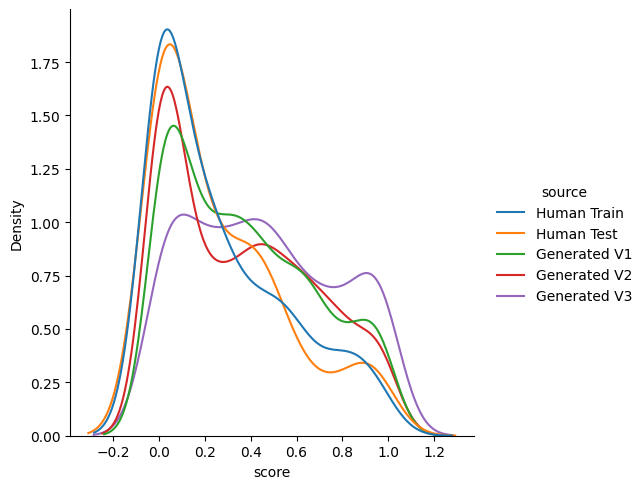

In [11]:
sns.displot(df.reset_index(drop=True), x="score", kind="kde", hue='source', common_norm=False)

In [29]:
import plotly.express as px
import plotly.figure_factory as ff
colors = ['#D81B60', '#1E88E5', '#004D40']

fig = ff.create_distplot(list(ds_scores.values()), list(ds_scores.keys()), 
                        bin_size=1,show_rug=False,show_hist=False,
                        colors=colors)
fig.update_layout(xaxis_title="Answer Confidence Score", yaxis_title="Density",
                plot_bgcolor='rgba(0,0,0,0)',
                font=dict(size=26),
                legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="center",
                x=0.5
            ))

fig.update_xaxes(showline=True, linewidth=2, linecolor='darkgrey', gridcolor='darkgrey', range=[0, 1.0])
fig.update_yaxes(showline=True, linewidth=2, linecolor='darkgrey', gridcolor='darkgrey')
fig.show()

fig.write_image('question_answerability.pdf', 'pdf', width=1300, height=600)

In [47]:
print("Confidence Scores")
for ds_key in ds_scores:
    print("===========")
    print( ds_key)
    print("Mean:", mean(ds_scores[ds_key]))
    print("Min:", min(ds_scores[ds_key]))
    print("Max:", max(ds_scores[ds_key]))

Confidence Scores
Human Train
Mean: 0.27008785335080937
Min: 4.474156878320201e-10
Max: 0.9946977496147156
Human Test
Mean: 0.26759337146270257
Min: 2.5254396351925834e-09
Max: 0.9843572974205017
Generated V1
Mean: 0.37814922169260246
Min: 5.190878837879609e-09
Max: 0.9981724619865417
Generated V2
Mean: 0.3606413473331441
Min: 2.2606033711625173e-10
Max: 0.995732307434082
Generated V3
Mean: 0.45530065616486154
Min: 4.359430316736024e-10
Max: 0.9962469339370728


In [17]:
# Extract some bad example qa pairs
bad_questions = {}

for dataset_name in datasets:
    data = torch.load(f"llama_{dataset_name}_qa_scores.pt")
    print(dataset_name, "#questions:", len(dataset.question_list), "#scores:", len(scores))
    bad_questions[dataset_name] = []
    for item in data:
        if item["score"] < 0.0001:
            bad_questions[dataset_name].append(item)

        # if len(bad_questions[dataset_name]) > 5:
        #     break

/tmp/ipykernel_948977/3138436049.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f"llama_{dataset_name}_qa_scores.pt")


Human Train #questions: 416 #scores: 416
Human Test #questions: 416 #scores: 416
Generated V1 #questions: 416 #scores: 416
Generated V2 #questions: 416 #scores: 416
Generated V3 #questions: 416 #scores: 416


In [18]:
bad_questions['Human Train']

[{'question': 'Can I book first class?',
  'context': 'Booking a "Business"  class ticket is allowed on flights which last more than 10 uninterrupted hours. Otherwise, only the cheapest flight class is reimbursable. A seat reservation is not reimbursable.',
  'score': 1.0565463526290841e-06},
 {'question': 'Can I book regional transportation?',
  'context': "You can book train tickets yourself (through the DB website, at their counter / ticket machine) or through the university's partner travel agency (Tel. +123456789). You can find contact information for the partner travel agency here.",
  'score': 3.0357188734342344e-05},
 {'question': 'What is counted as an ancillary cost?',
  'context': 'Incidental costs are, e.g.,: Insurances Visa fees \n Conference meals \n Parking fees \n Oversized baggage fees \n Conference fees \n Credit card fees \n Cloakroom fees \n Entrance costs \n Postage costs \n Vaccinations',
  'score': 2.6330551463615848e-06},
 {'question': 'What trainings are offere

In [19]:
bad_questions['Generated V3']

[{'question': 'What is the cheapest flight class that is reimbursable for flights under 10 uninterrupted hours?',
  'context': 'Booking a "Business"  class ticket is allowed on flights which last more than 10 uninterrupted hours. Otherwise, only the cheapest flight class is reimbursable. A seat reservation is not reimbursable.',
  'score': 6.66122796246782e-05},
 {'question': 'Can I skip asking my supervisor for an intracity trip?',
  'context': "Verbal permission is required from your supervisor for an intracity business trip. Please don't forget to get this. Written permission is not necessary",
  'score': 6.588502583326772e-05},
 {'question': 'What is the role of RKI in providing travel warnings and restrictions related to COVID-19?',
  'context': 'Please check the current COVID-19 travel warnings travel restrictions from the foreign ministry and the RKI. Business trips to high risk areas or virus variation areas are not generally not allowed. In In extreme cases, authorization can 